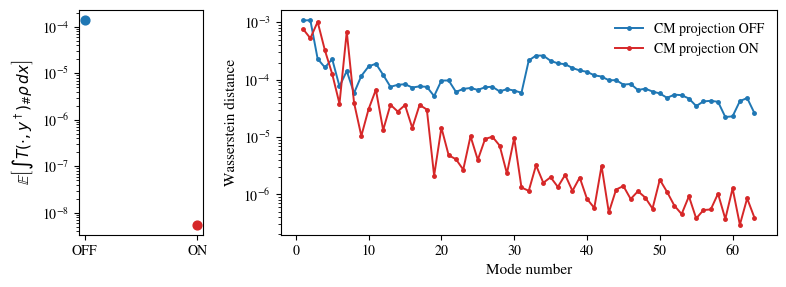

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------------------
# Paper-style plotting
# -----------------------------------------
mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.4,
})

# -----------------------------------------
# Colors (same for both plots)
# -----------------------------------------
colors = {
    "CM projection OFF": "#1f77b4",
    "CM projection ON": "#d62728",
}

# -----------------------------------------
# Load Wasserstein results
# -----------------------------------------
load_names = [
    "./../../Data/Experiment3/wasserstein_T_prior_bestCMOFF.npz",
    "./../../Data/Experiment3/wasserstein_T_prior_bestCMON.npz",
]

wasserstein_results = {}

for fname in load_names:
    data = np.load(fname, allow_pickle=True)

    if "CMOFF" in fname:
        label = "CM projection OFF"
    elif "CMON" in fname:
        label = "CM projection ON"

    wasserstein_results[label] = data["per_mode"]

# -----------------------------------------
# Load pushforward samples and compute mean
# -----------------------------------------
pushforward_files = [
    "./../../Data/Experiment3/pushforward_samples_T_prior_bestCMOFF.npz",
    "./../../Data/Experiment3/pushforward_samples_T_prior_bestCMON.npz",
]

pushforward_means = {}

for fname in pushforward_files:
    data = np.load(fname, allow_pickle=True)
    samples = data["pushforward_samples"]

    if "CMOFF" in fname:
        label = "CM projection OFF"
    elif "CMON" in fname:
        label = "CM projection ON"

    pushforward_means[label] = np.abs(samples.mean())

# -----------------------------------------
# Combined figure (1 row, width ratio 1:4)
# -----------------------------------------
labels = ["CM projection OFF", "CM projection ON"]
x_small = np.arange(len(labels))
y_small = [pushforward_means[label] for label in labels]

fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3),
    gridspec_kw={"width_ratios": [1, 4]}
)

# ---- Left plot (means) ----
for i, label in enumerate(labels):
    axes[0].scatter(
        x_small[i],
        y_small[i],
        s=40,
        color=colors[label]
    )

axes[0].set_yscale("log")
axes[0].set_xticks(x_small)
axes[0].set_xticklabels(["OFF", "ON"])
axes[0].set_ylabel(r"$\mathbb{E}\left[\int T(\cdot, y^\dagger)_{\#}\rho \, dx \right]$")

# ---- Right plot (Wasserstein per mode) ----
for label in labels:
    per_mode = wasserstein_results[label]
    axes[1].plot(
        np.arange(1, len(per_mode) + 1),
        per_mode,
        marker='o',
        ms=2.5,
        color=colors[label],
        label=label
    )

axes[1].set_xlabel("Mode number")
axes[1].set_ylabel("Wasserstein distance")
axes[1].set_yscale("log")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("./../../Figs/Experiment3/combined_wasserstein_mean.png", bbox_inches="tight",dpi=300)
plt.show()

Mean values:
CM projection OFF: 1.387117e-04
CM projection ON: 5.555153e-09


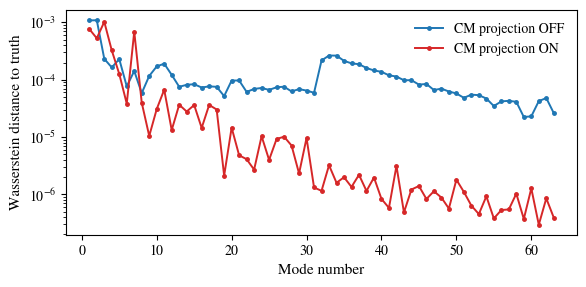

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------------------
# Paper-style plotting
# -----------------------------------------
mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.4,
})

# -----------------------------------------
# Colors
# -----------------------------------------
colors = {
    "CM projection OFF": "#1f77b4",
    "CM projection ON": "#d62728",
}

# -----------------------------------------
# Load Wasserstein results
# -----------------------------------------
load_names = [
    "./../../Data/Experiment3/wasserstein_T_prior_bestCMOFF.npz",
    "./../../Data/Experiment3/wasserstein_T_prior_bestCMON.npz",
]

wasserstein_results = {}

for fname in load_names:
    data = np.load(fname, allow_pickle=True)

    if "CMOFF" in fname:
        label = "CM projection OFF"
    elif "CMON" in fname:
        label = "CM projection ON"

    wasserstein_results[label] = data["per_mode"]

# -----------------------------------------
# Load pushforward samples and compute mean
# -----------------------------------------
pushforward_files = [
    "./../../Data/Experiment3/pushforward_samples_T_prior_bestCMOFF.npz",
    "./../../Data/Experiment3/pushforward_samples_T_prior_bestCMON.npz",
]

pushforward_means = {}

for fname in pushforward_files:
    data = np.load(fname, allow_pickle=True)
    samples = data["pushforward_samples"]

    if "CMOFF" in fname:
        label = "CM projection OFF"
    elif "CMON" in fname:
        label = "CM projection ON"

    pushforward_means[label] = np.abs(samples.mean())

# -----------------------------------------
# PRINT RESULTS (instead of left plot)
# -----------------------------------------
print("Mean values:")
for label in ["CM projection OFF", "CM projection ON"]:
    print(f"{label}: {pushforward_means[label]:.6e}")

# -----------------------------------------
# Right plot only (Wasserstein per mode)
# -----------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))

for label in ["CM projection OFF", "CM projection ON"]:
    per_mode = wasserstein_results[label]
    ax.plot(
        np.arange(1, len(per_mode) + 1),
        per_mode,
        marker='o',
        ms=2.5,
        color=colors[label],
        label=label
    )

ax.set_xlabel("Mode number")
ax.set_ylabel("Wasserstein distance to truth")
ax.set_yscale("log")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("./../../Figs/Experiment3/wasserstein_per_mode.png",
            bbox_inches="tight", dpi=300)
plt.show()